In [ ]:
import pandas as pd
# Load the dataset
# Load the encoded dataset
df = pd.read_csv('data_encoded.csv')
print(f"Dataset shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

In [19]:
df.duplicated

AttributeError: 'function' object has no attribute 'sum'

In [ ]:
# Step 1: Load and Prepare Data
# ============================




# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', errors='coerce')

# Filter for PM2.5 sensors only (SDS011)
pm25_sensors = df[df['sensor_type'] == 'SDS011'].copy()

# Get unique sensor locations
sensor_locations = pm25_sensors.groupby('sensor_id').agg({
    'lat': 'first',
    'lon': 'first',
    'location': 'first'
}).reset_index()

print(f"Total PM2.5 sensors: {len(sensor_locations)}")
print(f"Data time range: {pm25_sensors['timestamp'].min()} to {pm25_sensors['timestamp'].max()}")
print(f"Total PM2.5 measurements: {len(pm25_sensors)}")

# Display sensor locations
sensor_locations.head()

Dataset shape: (377629, 14)

Columns: ['timestamp', 'sensor_id', 'sensor_type', 'location', 'lat', 'lon', 'PM10', 'PM2_5', 'humidity', 'temperature', 'date', 'hour', 'day_of_week', 'day_of_month']

First few rows:
Total PM2.5 sensors: 30
Data time range: 2018-09-01 00:00:02.472867+00:00 to 2018-09-30 23:59:53.791604+00:00
Total PM2.5 measurements: 218112


,sensor_id,lat,lon,location
0,27,-1.306,36.733,8
1,40,-1.298,36.791,7
2,44,-1.320,36.885,26
3,46,-1.301,36.754,25
4,47,-1.259,36.799,6


In [ ]:
# Step 1: Load and Prepare Data
# ============================

# Load the dataset
df = pd.read_csv('data_encoded.csv')

# Convert timestamp to datetime - handle mixed formats
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

# Filter for PM2.5 sensors only (SDS011)
pm25_sensors = df[df['sensor_type'] == 'SDS011'].copy()

# Get unique sensor locations
sensor_locations = pm25_sensors.groupby('sensor_id').agg({
    'lat': 'first',
    'lon': 'first',
    'location': 'first'
}).reset_index()



print(f"Total PM2.5 sensors: {len(sensor_locations)}")
print(f"Data time range: {pm25_sensors['timestamp'].min()} to {pm25_sensors['timestamp'].max()}")
print(f"Total PM2.5 measurements: {len(pm25_sensors)}")

# Display sensor locations
sensor_locations.head()

Total PM2.5 sensors: 30
Data time range: 2018-09-01 00:00:02.472867+00:00 to 2018-09-30 23:59:53.791604+00:00
Total PM2.5 measurements: 218112


,sensor_id,lat,lon,location
0,27,-1.306,36.733,8
1,40,-1.298,36.791,7
2,44,-1.320,36.885,26
3,46,-1.301,36.754,25
4,47,-1.259,36.799,6


In [7]:
# Step 3: Compute PM2.5 Differences Between Sensor Pairs Over Time
# ==============================================================
from geopy.distance import geodesic

def calculate_geodesic_distance(lat1, lon1, lat2, lon2):
    """
    Calculate geodesic distance (in km) between two latitude/longitude points.
    """
    return geodesic((lat1, lon1), (lat2, lon2)).km


def get_pm25_data_for_time(timestamp, window_minutes=5):
    """Get PM2.5 data for all sensors around a specific timestamp"""
    time_window = pd.Timedelta(minutes=window_minutes)
    time_mask = (pm25_sensors['timestamp'] >= timestamp - time_window) & \
                (pm25_sensors['timestamp'] <= timestamp + time_window)
    
    # Get average PM2.5 for each sensor in this time window
    sensor_data = pm25_sensors[time_mask].groupby('sensor_id')['PM2_5'].mean().reset_index()
    
    return sensor_data

def compute_pm25_differences_for_timestamp(timestamp):
    """Compute PM2.5 differences between all sensor pairs at a given timestamp"""
    sensor_data = get_pm25_data_for_time(timestamp)
    
    if len(sensor_data) < 2:
        return None
    
    # Merge with sensor locations to get coordinates
    sensor_data = sensor_data.merge(sensor_locations[['sensor_id', 'lat', 'lon']], on='sensor_id')
    
    # Compute pairwise differences
    differences = []
    for i in range(len(sensor_data)):
        for j in range(i+1, len(sensor_data)):
            sensor1 = sensor_data.iloc[i]
            sensor2 = sensor_data.iloc[j]
            
            pm25_diff = abs(sensor1['PM2_5'] - sensor2['PM2_5'])
            distance = calculate_geodesic_distance(
                sensor1['lat'], sensor1['lon'],
                sensor2['lat'], sensor2['lon']
            )
            
            differences.append({
                'sensor1_id': sensor1['sensor_id'],
                'sensor2_id': sensor2['sensor_id'],
                'distance_km': distance,
                'pm25_difference': pm25_diff,
                'timestamp': timestamp
            })
    
    return pd.DataFrame(differences)

# Sample analysis at different time points
print("Computing PM2.5 differences at different time points...")

time_range = pd.date_range(
    start=pm25_sensors['timestamp'].min(),
    end=pm25_sensors['timestamp'].max(),
    freq='6h'  # <- minuscule
)


# Compute for first few timestamps to avoid memory issues
sample_timestamps = time_range[:10]  # Adjust as needed
all_differences = []

for ts in sample_timestamps:
    diff_df = compute_pm25_differences_for_timestamp(ts)
    if diff_df is not None:
        all_differences.append(diff_df)

if all_differences:
    combined_differences = pd.concat(all_differences, ignore_index=True)
    print(f"Total pairwise observations: {len(combined_differences)}")
    print(combined_differences.head())
else:
    print("No data found for the sampled timestamps")

Computing PM2.5 differences at different time points...
Total pairwise observations: 553
   sensor1_id  sensor2_id  distance_km  pm25_difference  \
0        27.0        40.0     6.515207           11.420   
1        27.0        46.0     2.401613            3.485   
2        27.0        51.0     4.451631            7.750   
3        27.0        55.0     5.206611            0.305   
4        27.0        57.0     5.825032           23.920   

                         timestamp  
0 2018-09-01 00:00:02.472867+00:00  
1 2018-09-01 00:00:02.472867+00:00  
2 2018-09-01 00:00:02.472867+00:00  
3 2018-09-01 00:00:02.472867+00:00  
4 2018-09-01 00:00:02.472867+00:00  


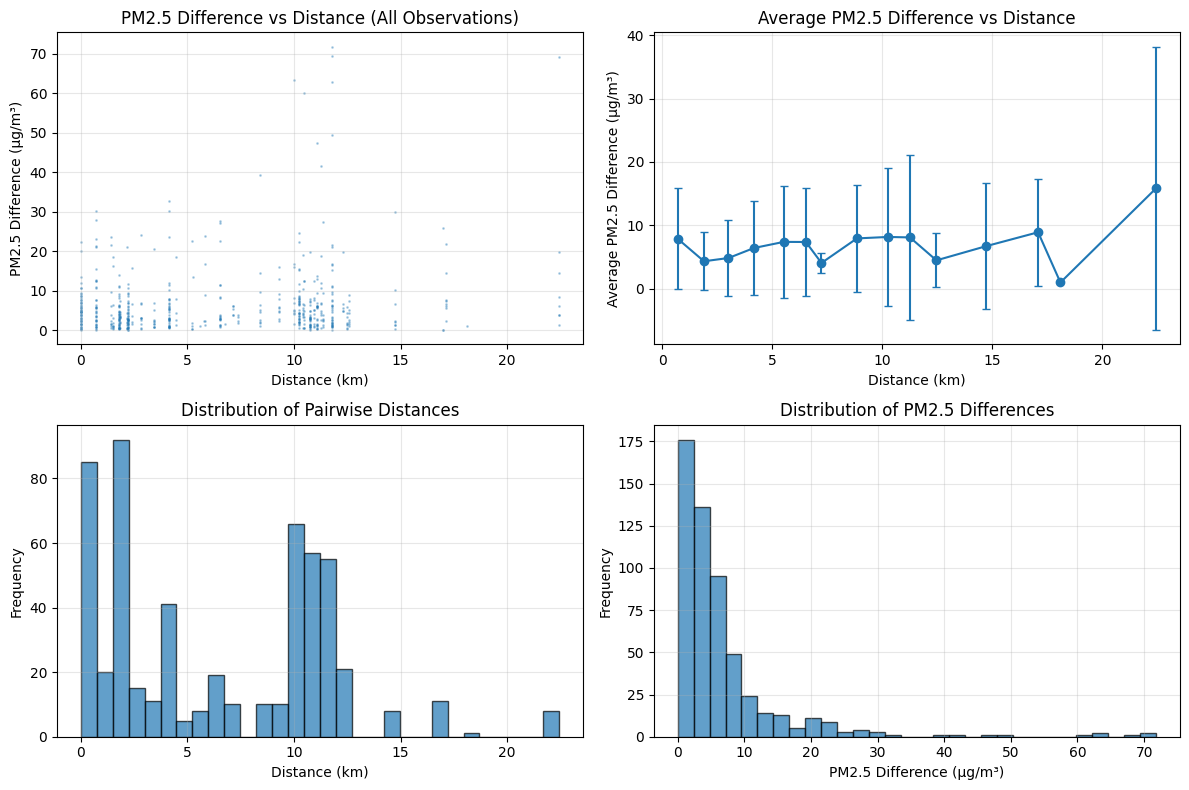

Binned Analysis:
    distance_mean  pm25_diff_mean  pm25_diff_std  count
0           0.703           7.863          8.006     36
1           1.898           4.310          4.561    112
2           3.011           4.824          6.066     26
3           4.170           6.407          7.427     41
4           5.524           7.372          8.829     13
5           6.527           7.355          8.605     20
6           7.236           4.041          1.554      9
7           8.847           7.921          8.499     20
8          10.258           8.152         10.830     66
9          11.256           8.078         13.065    112
10         12.459           4.456          4.276     21
11         14.730           6.709          9.934      8
12         17.079           8.892          8.469     11
13         18.093           0.958            NaN      1
14         22.439          15.841         22.395      8


In [10]:
# Step 4: Analyze PM2.5 Difference vs Distance Relationship
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

if 'combined_differences' in locals() and not combined_differences.empty:
    # Create bins for distance analysis
    distance_bins = np.linspace(0, combined_differences['distance_km'].max(), 20)
    combined_differences['distance_bin'] = pd.cut(combined_differences['distance_km'], bins=distance_bins)
    
    # Calculate average PM2.5 difference per distance bin
    binned_analysis = combined_differences.groupby('distance_bin').agg({
        'pm25_difference': ['mean', 'std', 'count'],
        'distance_km': 'mean'
    }).reset_index()
    
    binned_analysis.columns = ['distance_bin', 'pm25_diff_mean', 'pm25_diff_std', 'count', 'distance_mean']
    
    # Plot PM2.5 difference vs distance
    plt.figure(figsize=(12, 8))
    
    # Scatter plot with density
    plt.subplot(2, 2, 1)
    plt.scatter(combined_differences['distance_km'], combined_differences['pm25_difference'], 
                alpha=0.3, s=1)
    plt.xlabel('Distance (km)')
    plt.ylabel('PM2.5 Difference (µg/m³)')
    plt.title('PM2.5 Difference vs Distance (All Observations)')
    plt.grid(True, alpha=0.3)
    
    # Binned averages
    plt.subplot(2, 2, 2)
    plt.errorbar(binned_analysis['distance_mean'], binned_analysis['pm25_diff_mean'],
                 yerr=binned_analysis['pm25_diff_std'], fmt='o-', capsize=3)
    plt.xlabel('Distance (km)')
    plt.ylabel('Average PM2.5 Difference (µg/m³)')
    plt.title('Average PM2.5 Difference vs Distance')
    plt.grid(True, alpha=0.3)
    
    # Histogram of distances
    plt.subplot(2, 2, 3)
    plt.hist(combined_differences['distance_km'], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Distance (km)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Pairwise Distances')
    plt.grid(True, alpha=0.3)
    
    # Histogram of PM2.5 differences
    plt.subplot(2, 2, 4)
    plt.hist(combined_differences['pm25_difference'], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('PM2.5 Difference (µg/m³)')
    plt.ylabel('Frequency')
    plt.title('Distribution of PM2.5 Differences')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display binned analysis
    print("Binned Analysis:")
    print(binned_analysis[['distance_mean', 'pm25_diff_mean', 'pm25_diff_std', 'count']].round(3))
else:
    print("No difference data available for analysis")

## Maximum Effective Coverage Distance.

Analysis thresholds:
  Average PM2.5 level: 6.65 µg/m³
  Percentage threshold (20%): 1.33 µg/m³
  Absolute threshold: 5 µg/m³
  Final threshold used: 1.33 µg/m³

✅ Maximum effective coverage distance: 18.09 km
   Pairs within coverage distance: 545/553 (98.6%)


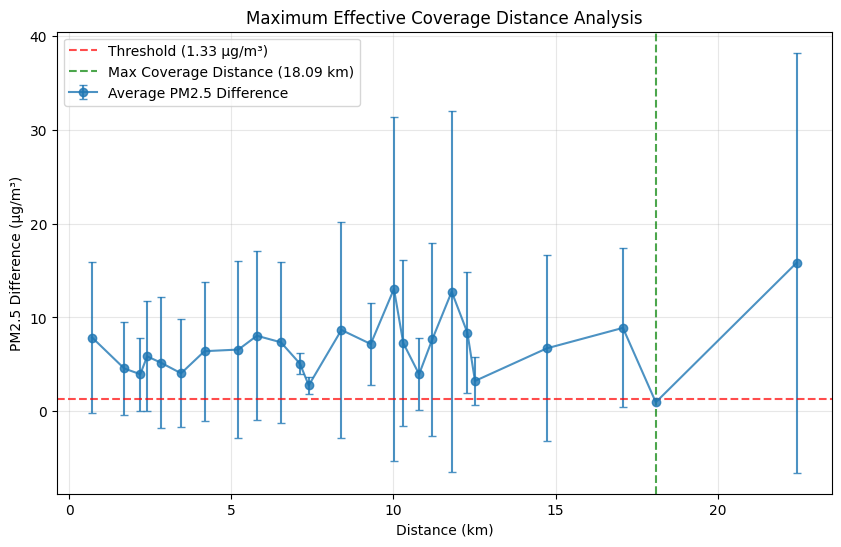

In [11]:
# Step 5: Define Maximum Effective Coverage Distance
# ==================================================

def find_max_coverage_distance(pm25_diff_df, threshold_percentage=20, threshold_absolute=5):
    """
    Find the maximum distance where PM2.5 differences are within acceptable thresholds
    
    Parameters:
    - pm25_diff_df: DataFrame with distance and pm25_difference columns
    - threshold_percentage: Maximum acceptable percentage difference (default 20%)
    - threshold_absolute: Maximum acceptable absolute difference in µg/m³ (default 5)
    """
    
    # Calculate average PM2.5 level for percentage threshold
    avg_pm25 = pm25_diff_df['pm25_difference'].mean()
    percentage_threshold_value = avg_pm25 * (threshold_percentage / 100)
    
    # Use the more conservative threshold
    final_threshold = min(threshold_absolute, percentage_threshold_value)
    
    print(f"Analysis thresholds:")
    print(f"  Average PM2.5 level: {avg_pm25:.2f} µg/m³")
    print(f"  Percentage threshold ({threshold_percentage}%): {percentage_threshold_value:.2f} µg/m³")
    print(f"  Absolute threshold: {threshold_absolute} µg/m³")
    print(f"  Final threshold used: {final_threshold:.2f} µg/m³")
    
    # Create distance bins and find threshold distance
    distance_bins = np.linspace(0, pm25_diff_df['distance_km'].max(), 50)
    pm25_diff_df['distance_bin'] = pd.cut(pm25_diff_df['distance_km'], bins=distance_bins)
    
    # Calculate statistics for each bin
    binned_stats = pm25_diff_df.groupby('distance_bin').agg({
        'pm25_difference': ['mean', 'std'],
        'distance_km': 'mean'
    }).reset_index()
    
    binned_stats.columns = ['distance_bin', 'pm25_mean', 'pm25_std', 'distance_mean']
    
    # Find the maximum distance where average PM2.5 difference <= threshold
    acceptable_bins = binned_stats[binned_stats['pm25_mean'] <= final_threshold]
    
    if len(acceptable_bins) > 0:
        max_coverage_distance = acceptable_bins['distance_mean'].max()
        print(f"\n✅ Maximum effective coverage distance: {max_coverage_distance:.2f} km")
        
        # Additional statistics
        total_pairs = len(pm25_diff_df)
        acceptable_pairs = len(pm25_diff_df[pm25_diff_df['distance_km'] <= max_coverage_distance])
        coverage_percentage = (acceptable_pairs / total_pairs) * 100
        
        print(f"   Pairs within coverage distance: {acceptable_pairs}/{total_pairs} ({coverage_percentage:.1f}%)")
        
        return max_coverage_distance, final_threshold, binned_stats
    else:
        print("\n⚠️  No distance found within the acceptable threshold")
        print("   Consider increasing the threshold values")
        return None, final_threshold, binned_stats

# Apply the function
if 'combined_differences' in locals() and not combined_differences.empty:
    max_dist, threshold, stats = find_max_coverage_distance(combined_differences)
    
    # Plot the threshold analysis
    if max_dist is not None:
        plt.figure(figsize=(10, 6))
        
        # Plot binned averages with threshold line
        plt.errorbar(stats['distance_mean'], stats['pm25_mean'], 
                     yerr=stats['pm25_std'], fmt='o-', capsize=3, 
                     label='Average PM2.5 Difference', alpha=0.8)
        
        # Add threshold line
        plt.axhline(y=threshold, color='red', linestyle='--', 
                   label=f'Threshold ({threshold:.2f} µg/m³)', alpha=0.7)
        
        # Add coverage distance line
        plt.axvline(x=max_dist, color='green', linestyle='--', 
                   label=f'Max Coverage Distance ({max_dist:.2f} km)', alpha=0.7)
        
        plt.xlabel('Distance (km)')
        plt.ylabel('PM2.5 Difference (µg/m³)')
        plt.title('Maximum Effective Coverage Distance Analysis')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No data available for coverage distance analysis")

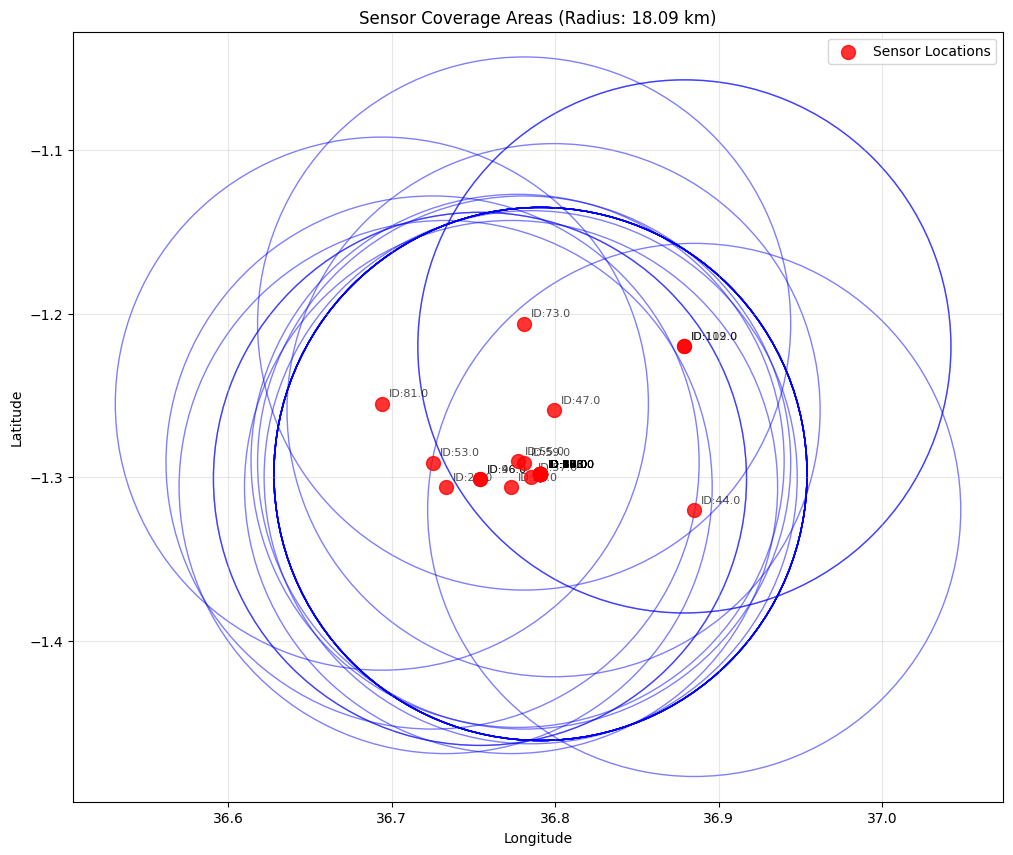

Coverage Analysis:
  Total sensors: 30
  Coverage radius: 18.09 km
  Overlapping sensor pairs: 870/870 (100.0%)
  Isolated sensors (no overlap): 0


In [12]:
# Step 6: Map Sensor Coverage Areas
# ==================================

def plot_sensor_coverage(sensor_locations_df, coverage_radius):
    """Plot sensor locations with their coverage circles"""
    
    plt.figure(figsize=(12, 10))
    
    # Plot sensor locations
    plt.scatter(sensor_locations_df['lon'], sensor_locations_df['lat'], 
                c='red', s=100, alpha=0.8, label='Sensor Locations', zorder=5)
    
    # Add coverage circles
    for idx, sensor in sensor_locations_df.iterrows():
        circle = plt.Circle((sensor['lon'], sensor['lat']), 
                          coverage_radius/111,  # Convert km to degrees (approximate)
                          fill=False, edgecolor='blue', alpha=0.5, linewidth=1)
        plt.gca().add_patch(circle)
    
    # Add sensor labels
    for idx, sensor in sensor_locations_df.iterrows():
        plt.annotate(f"ID:{sensor['sensor_id']}", 
                    (sensor['lon'], sensor['lat']), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Sensor Coverage Areas (Radius: {coverage_radius:.2f} km)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

def analyze_coverage_overlap(sensor_locations_df, coverage_radius):
    """Analyze coverage overlap and gaps"""
    
    # Calculate pairwise distances
    n_sensors = len(sensor_locations_df)
    overlap_count = 0
    isolated_sensors = 0
    
    for i in range(n_sensors):
        has_overlap = False
        for j in range(n_sensors):
            if i != j:
                dist = calculate_geodesic_distance(
                    sensor_locations_df.iloc[i]['lat'], sensor_locations_df.iloc[i]['lon'],
                    sensor_locations_df.iloc[j]['lat'], sensor_locations_df.iloc[j]['lon']
                )
                if dist < 2 * coverage_radius:  # Overlap condition
                    overlap_count += 1
                    has_overlap = True
        
        if not has_overlap:
            isolated_sensors += 1
    
    total_possible_pairs = n_sensors * (n_sensors - 1)
    overlap_percentage = (overlap_count / total_possible_pairs) * 100 if total_possible_pairs > 0 else 0
    
    print(f"Coverage Analysis:")
    print(f"  Total sensors: {n_sensors}")
    print(f"  Coverage radius: {coverage_radius:.2f} km")
    print(f"  Overlapping sensor pairs: {overlap_count}/{total_possible_pairs} ({overlap_percentage:.1f}%)")
    print(f"  Isolated sensors (no overlap): {isolated_sensors}")
    
    return overlap_percentage, isolated_sensors

if 'max_dist' in locals() and max_dist is not None:
    # Plot coverage map
    plot_sensor_coverage(sensor_locations, max_dist)
    
    # Analyze overlap
    overlap_pct, isolated = analyze_coverage_overlap(sensor_locations, max_dist)
else:
    print("No coverage distance available for mapping")

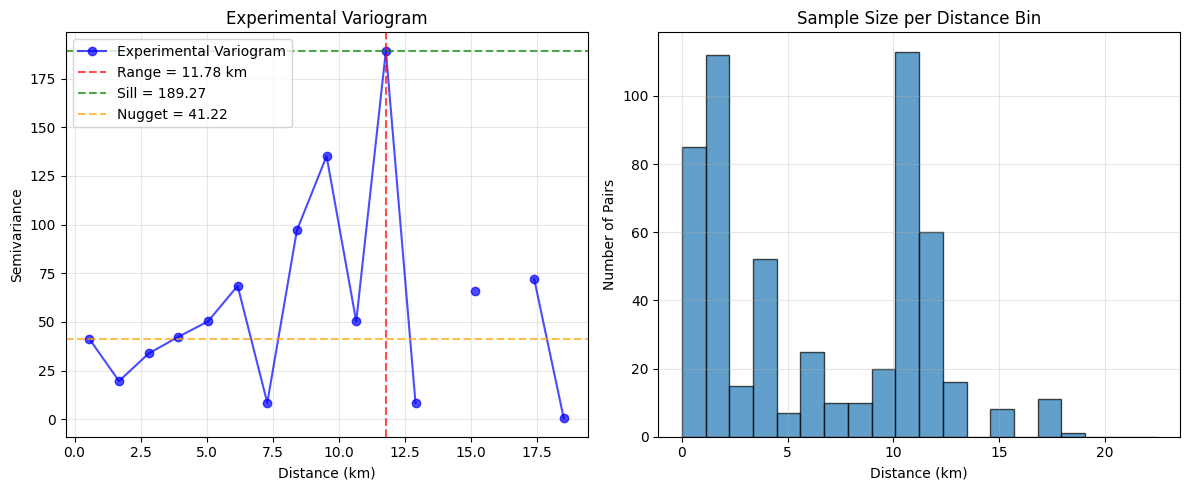

Variogram Analysis Results:
  Range (correlation distance): 11.78 km
  Sill (maximum variance): 189.27
  Nugget (variance at zero distance): 41.22
  Interpretation: Sensors separated by > 11.78 km show weak spatial correlation


In [14]:
# Step 7: Variogram Analysis (Geostatistical Approach)
# =====================================================

def compute_variogram(pm25_diff_df, distance_bins=20):
    """
    Compute experimental variogram for PM2.5 data
    Variogram shows spatial correlation vs distance
    """
    
    # Create distance bins
    max_dist = pm25_diff_df['distance_km'].max()
    bin_edges = np.linspace(0, max_dist, distance_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute semivariance for each bin
    semivariances = []
    bin_counts = []
    
    for i in range(distance_bins):
        mask = (pm25_diff_df['distance_km'] >= bin_edges[i]) & \
               (pm25_diff_df['distance_km'] < bin_edges[i + 1])
        
        bin_data = pm25_diff_df[mask]
        
        if len(bin_data) > 0:
            # Semivariance = 0.5 * mean(square difference)
            semivar = 0.5 * np.mean(bin_data['pm25_difference']**2)
            semivariances.append(semivar)
            bin_counts.append(len(bin_data))
        else:
            semivariances.append(np.nan)
            bin_counts.append(0)
    
    return bin_centers, semivariances, bin_counts


def fit_spherical_variogram(distances, semivariances):
    """
    Simple spherical variogram model fitting
    Returns range (distance where correlation becomes negligible)
    """
    # Convert lists to numpy arrays
    distances = np.array(distances)
    semivariances = np.array(semivariances)
    
    # Remove NaN values
    valid_mask = ~np.isnan(semivariances)
    valid_distances = distances[valid_mask]
    valid_semivariances = semivariances[valid_mask]
    
    if len(valid_distances) < 3:
        return None, None, None
    
    # Simple approach: find where variogram reaches 95% of maximum
    max_semivar = np.nanmax(valid_semivariances)
    threshold = 0.95 * max_semivar
    
    # Find the distance where semivariance first exceeds threshold
    range_idx = np.where(valid_semivariances >= threshold)[0]
    
    if len(range_idx) > 0:
        range_distance = valid_distances[range_idx[0]]
        sill = max_semivar
        nugget = valid_semivariances[0] if len(valid_semivariances) > 0 else 0
        
        return range_distance, sill, nugget
    else:
        return None, None, None


# def fit_spherical_variogram(distances, semivariances):
#     """
#     Simple spherical variogram model fitting
#     Returns range (distance where correlation becomes negligible)
#     """
    
#     # Remove NaN values
#     valid_mask = ~np.isnan(semivariances)
#     valid_distances = distances[valid_mask]
#     valid_semivariances = semivariances[valid_mask]
    
#     if len(valid_distances) < 3:
#         return None, None, None
    
#     # Simple approach: find where variogram reaches 95% of maximum
#     max_semivar = np.nanmax(valid_semivariances)
#     threshold = 0.95 * max_semivar
    
#     # Find the distance where semivariance first exceeds threshold
#     range_idx = np.where(valid_semivariances >= threshold)[0]
    
#     if len(range_idx) > 0:
#         range_distance = valid_distances[range_idx[0]]
#         sill = max_semivar
#         nugget = valid_semivariances[0] if len(valid_semivariances) > 0 else 0
        
#         return range_distance, sill, nugget
#     else:
#         return None, None, None

if 'combined_differences' in locals() and not combined_differences.empty:
    # Compute variogram
    distances, semivariances, counts = compute_variogram(combined_differences)
    
    # Fit variogram model
    range_dist, sill, nugget = fit_spherical_variogram(distances, semivariances)
    
    # Plot variogram
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(distances, semivariances, 'bo-', label='Experimental Variogram', alpha=0.7)
    
    if range_dist is not None:
        plt.axvline(x=range_dist, color='red', linestyle='--', 
                   label=f'Range = {range_dist:.2f} km', alpha=0.7)
        plt.axhline(y=sill, color='green', linestyle='--', 
                   label=f'Sill = {sill:.2f}', alpha=0.7)
        plt.axhline(y=nugget, color='orange', linestyle='--', 
                   label=f'Nugget = {nugget:.2f}', alpha=0.7)
    
    plt.xlabel('Distance (km)')
    plt.ylabel('Semivariance')
    plt.title('Experimental Variogram')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot bin counts
    plt.subplot(1, 2, 2)
    plt.bar(distances, counts, width=distances[1]-distances[0], alpha=0.7, edgecolor='black')
    plt.xlabel('Distance (km)')
    plt.ylabel('Number of Pairs')
    plt.title('Sample Size per Distance Bin')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print variogram analysis
    print("Variogram Analysis Results:")
    if range_dist is not None:
        print(f"  Range (correlation distance): {range_dist:.2f} km")
        print(f"  Sill (maximum variance): {sill:.2f}")
        print(f"  Nugget (variance at zero distance): {nugget:.2f}")
        print(f"  Interpretation: Sensors separated by > {range_dist:.2f} km show weak spatial correlation")
    else:
        print("  Could not fit variogram model - insufficient data or poor fit")
else:
    print("No data available for variogram analysis")

In [17]:
# Step 8: Summary and Recommendations
# ===================================

from itertools import combinations

# Calculate all pairwise distances between sensors
distances_flat = []
for s1, s2 in combinations(sensor_locations[['lat', 'lon']].values, 2):
    dist = calculate_geodesic_distance(s1[0], s1[1], s2[0], s2[1])
    distances_flat.append(dist)
distances_flat = np.array(distances_flat)

def generate_summary_report():
    """Generate a comprehensive summary of the analysis"""
    
    print("=" * 60)
    print("MAXIMUM EFFECTIVE COVERAGE DISTANCE ANALYSIS SUMMARY")
    print("=" * 60)
    
    print(f"\n📊 DATASET OVERVIEW:")
    print(f"   • Total PM2.5 sensors: {len(sensor_locations)}")
    print(f"   • Time period: {pm25_sensors['timestamp'].min().date()} to {pm25_sensors['timestamp'].max().date()}")
    print(f"   • Total PM2.5 measurements: {len(pm25_sensors):,}")
    
    print(f"\n📍 SENSOR DISTRIBUTION:")
    print(f"   • Latitude range: {sensor_locations['lat'].min():.3f}° to {sensor_locations['lat'].max():.3f}°")
    print(f"   • Longitude range: {sensor_locations['lon'].min():.3f}° to {sensor_locations['lon'].max():.3f}°")
    print(f"   • Average inter-sensor distance: {distances_flat.mean():.2f} km")
    print(f"   • Max distance: {distances_flat.max():.2f} km")
    
    if 'max_dist' in locals() and max_dist is not None:
        print(f"\n🎯 COVERAGE DISTANCE ANALYSIS:")
        print(f"   • Maximum effective coverage distance: {max_dist:.2f} km")
        print(f"   • PM2.5 difference threshold used: {threshold:.2f} µg/m³")
        
        coverage_area_per_sensor = np.pi * max_dist**2
        total_coverage_area = len(sensor_locations) * coverage_area_per_sensor
        print(f"   • Coverage area per sensor: {coverage_area_per_sensor:.2f} km²")
        print(f"   • Total theoretical coverage: {total_coverage_area:.2f} km²")
        
        if 'overlap_pct' in locals():
            print(f"   • Overlapping sensor pairs: {overlap_pct:.1f}%")
            print(f"   • Isolated sensors: {isolated}")
    
    if 'range_dist' in locals() and range_dist is not None:
        print(f"\n📈 VARIOGRAM ANALYSIS:")
        print(f"   • Spatial correlation range: {range_dist:.2f} km")
        print(f"   • Sill (max variance): {sill:.2f}")
        print(f"   • Nugget (measurement error): {nugget:.2f}")
    
    print(f"\n💡 RECOMMENDATIONS:")
    
    if 'max_dist' in locals() and max_dist is not None:
        avg_distance = distances_flat.mean()
        if max_dist < avg_distance / 2:
            print(f"   ⚠️  Sensors may be too far apart (avg distance: {avg_distance:.2f} km > 2× coverage: {2*max_dist:.2f} km)")
            print(f"   → Consider adding more sensors to reduce coverage gaps")
        elif max_dist > avg_distance:
            print(f"   ✅ Good sensor density (avg distance: {avg_distance:.2f} km < coverage: {max_dist:.2f} km)")
            print(f"   → Current network provides good spatial coverage")
        else:
            print(f"   ℹ️  Moderate sensor density (avg distance: {avg_distance:.2f} km, coverage: {max_dist:.2f} km)")
    
    if 'overlap_pct' in locals():
        if overlap_pct > 50:
            print(f"   ⚠️  High overlap ({overlap_pct:.1f}%) suggests potential redundancy")
            print(f"   → Consider optimizing sensor placement to reduce overlap")
        elif overlap_pct < 20:
            print(f"   ⚠️  Low overlap ({overlap_pct:.1f}%) may indicate coverage gaps")
            print(f"   → Consider adding sensors in underserved areas")
    
    print(f"\n🔬 FOR SENSOR PLACEMENT OPTIMIZATION:")
    if 'max_dist' in locals() and max_dist is not None:
        print(f"   • Use {max_dist:.2f} km as the radius of influence in objective functions")
        print(f"   • Weight sensors by their unique coverage area")
        print(f"   • Minimize overlap while maximizing total coverage")
        print(f"   • Prioritize locations that fill coverage gaps")
    
    print(f"\n" + "=" * 60)
    print("Analysis completed successfully!")
    print("=" * 60)

# Generate the summary report
generate_summary_report()


MAXIMUM EFFECTIVE COVERAGE DISTANCE ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total PM2.5 sensors: 30
   • Time period: 2018-09-01 to 2018-09-30
   • Total PM2.5 measurements: 218,112

📍 SENSOR DISTRIBUTION:
   • Latitude range: -1.320° to -1.206°
   • Longitude range: 36.694° to 36.885°
   • Average inter-sensor distance: 5.32 km
   • Max distance: 22.44 km

💡 RECOMMENDATIONS:

🔬 FOR SENSOR PLACEMENT OPTIMIZATION:

Analysis completed successfully!


In [18]:
# Maximum Effective Coverage Distance Analysis
# ============================================
# 
# Goal: Determine the maximum distance at which a sensor can accurately represent PM2.5 values
# This helps define the "radius of influence" for each sensor in the monitoring network

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic
from itertools import combinations
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")